In [1]:
"""
# Telco Churn EDA (01)

This notebook focuses on **understanding** the dataset (`telco_churn.csv`) only:
- Class balance (Churn distribution)
- Missingness overview
- Top categorical levels
- A few numeric distributions

✅ No modeling in this notebook.

Exports 1–2 key figures to `reports/figures/`.
"""

'\n# Telco Churn EDA (01)\n\nThis notebook focuses on **understanding** the dataset (`telco_churn.csv`) only:\n- Class balance (Churn distribution)\n- Missingness overview\n- Top categorical levels\n- A few numeric distributions\n\n✅ No modeling in this notebook.\n\nExports 1–2 key figures to `reports/figures/`.\n'

In [2]:
from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Project root (assumes you run notebook from repo root)
PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT))

In [14]:
PROJECT_ROOT

PosixPath('/workspaces/DataScience')

In [15]:
RAW_CSV = PROJECT_ROOT /"applied-ml-churn" / "data" / "raw" / "telco_churn.csv"
FIG_DIR = PROJECT_ROOT /"applied-ml-churn" / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw CSV:", RAW_CSV)
print("Figures dir:", FIG_DIR)

Project root: /workspaces/DataScience
Raw CSV: /workspaces/DataScience/applied-ml-churn/data/raw/telco_churn.csv
Figures dir: /workspaces/DataScience/applied-ml-churn/reports/figures


In [17]:
if not RAW_CSV.exists():
    raise FileNotFoundError(
        f"Expected {RAW_CSV} to exist. Put telco_churn.csv in data/raw/ or update RAW_CSV."
    )

df_raw = pd.read_csv(RAW_CSV)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
def standardize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """lowercase + underscores, collapse underscores, strip edges"""
    def _clean(col: str) -> str:
        col = col.strip().lower()
        col = re.sub(r"[^a-z0-9]+", "_", col)
        col = re.sub(r"_+", "_", col).strip("_")
        return col

    df = df.copy()
    df.columns = [_clean(c) for c in df.columns]
    return df

df = standardize_column_names(df_raw)

# Treat blank/whitespace-only strings as missing
df = df.replace(r"^\s*$", np.nan, regex=True)

# TotalCharges is often string with blanks in telco churn dataset; coerce if present
if "total_charges" in df.columns:
    df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

print("Columns:", list(df.columns))
df.head()

Columns: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [21]:
"""
## 1) Class balance
We check the distribution of the target (`churn`) to understand imbalance.
"""

'\n## 1) Class balance\nWe check the distribution of the target (`churn`) to understand imbalance.\n'

,count,proportion
churn,,
No,5174,0.73463
Yes,1869,0.26537


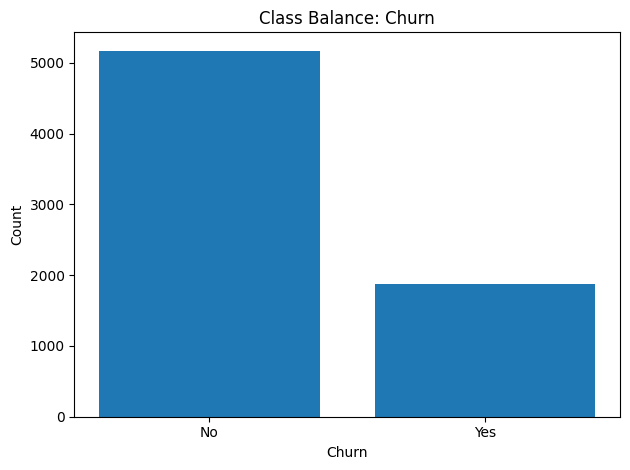

Saved: /workspaces/DataScience/applied-ml-churn/reports/figures/class_balance_churn.png


In [22]:
if "churn" not in df.columns:
    raise ValueError("Expected a 'churn' column in the dataset.")

churn_counts = df["churn"].value_counts(dropna=False)
churn_props = df["churn"].value_counts(normalize=True, dropna=False)

display(pd.DataFrame({"count": churn_counts, "proportion": churn_props}))

# Plot + export
fig, ax = plt.subplots()
ax.bar(churn_counts.index.astype(str), churn_counts.values)
ax.set_title("Class Balance: Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
fig.tight_layout()

out_path = FIG_DIR / "class_balance_churn.png"
fig.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

In [23]:
"""
## 2) Missingness overview
We summarize missing values per column.
"""

'\n## 2) Missingness overview\nWe summarize missing values per column.\n'

In [24]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]

missing_df.head(20)

,missing_count,missing_pct
totalcharges,11,0.156183


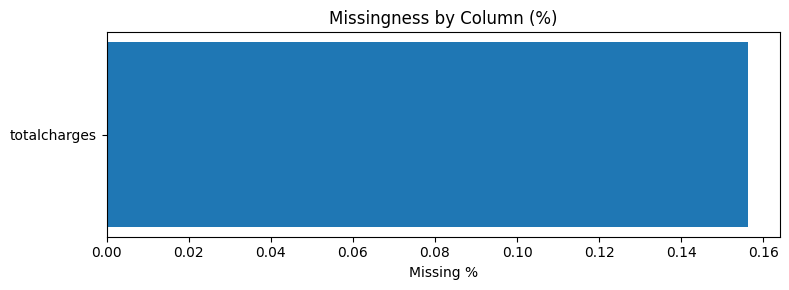

Saved: /workspaces/DataScience/applied-ml-churn/reports/figures/missingness_by_column.png


In [25]:
# Optional export: missingness bar chart (counts as a figure if there is missingness)
if len(missing_df) == 0:
    print("No missing values detected after cleaning blanks.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(missing_df))))
    ax.barh(missing_df.index[::-1], missing_df["missing_pct"][::-1].values)
    ax.set_title("Missingness by Column (%)")
    ax.set_xlabel("Missing %")
    fig.tight_layout()

    out_path = FIG_DIR / "missingness_by_column.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)

In [26]:
id_like = {"customerid"}   # adjust if your id column differs
target_col = "churn"

cat_cols = [
    c for c in df.columns
    if c not in id_like and c != target_col and (df[c].dtype == "object" or str(df[c].dtype) == "string")
]

print("Categorical columns:", cat_cols)

for c in cat_cols:
    vc = df[c].value_counts(dropna=False).head(10)
    print("\n" + "=" * 80)
    print(f"{c} (top 10 levels)")
    display(vc.to_frame("count"))

Categorical columns: []


In [27]:
"""
## 4) Numeric distributions (a couple)
We plot a few numeric columns to understand ranges and skew.
Common numeric columns: `tenure`, `monthly_charges`, `total_charges`.
"""

'\n## 4) Numeric distributions (a couple)\nWe plot a few numeric columns to understand ranges and skew.\nCommon numeric columns: `tenure`, `monthly_charges`, `total_charges`.\n'

Numeric columns: ['seniorcitizen', 'tenure', 'monthlycharges']
Plotting: ['tenure']


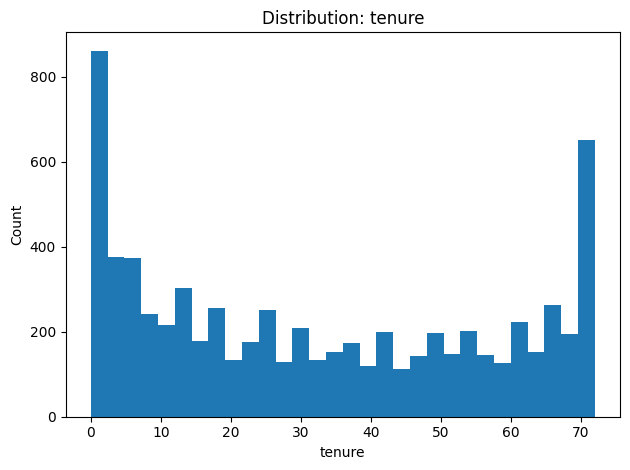

In [28]:
num_cols = [
    c for c in df.columns
    if c not in id_like and c != target_col and pd.api.types.is_numeric_dtype(df[c])
]
print("Numeric columns:", num_cols)

candidates = [c for c in ["tenure", "monthly_charges", "total_charges"] if c in df.columns]
if not candidates:
    candidates = num_cols[:2]

print("Plotting:", candidates)

for c in candidates:
    fig, ax = plt.subplots()
    ax.hist(df[c].dropna().values, bins=30)
    ax.set_title(f"Distribution: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
    fig.tight_layout()
    plt.show()

In [29]:
"""
## Export 2nd key figure: churn rate by contract (recommended)
This is a common churn driver. Export to `reports/figures/`.
"""

'\n## Export 2nd key figure: churn rate by contract (recommended)\nThis is a common churn driver. Export to `reports/figures/`.\n'

,churn_rate
contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


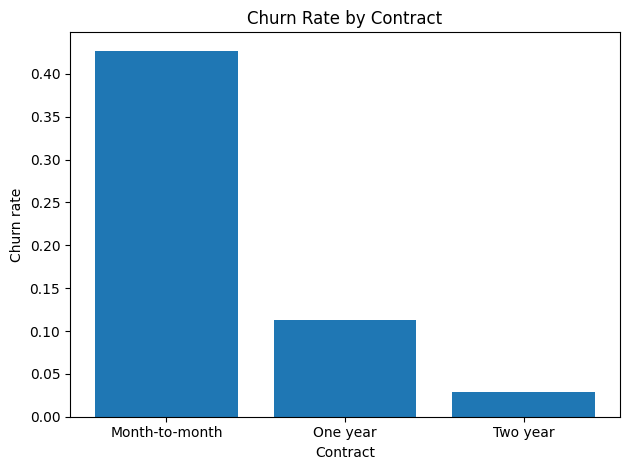

Saved: /workspaces/DataScience/applied-ml-churn/reports/figures/churn_rate_by_contract.png


In [30]:
# Export 2nd key figure (kept simple)
if "contract" in df.columns:
    churn_yes = df["churn"].astype(str).str.strip().str.lower().eq("yes").astype(int)
    churn_rate = (
        df.assign(churn_yes=churn_yes)
          .groupby("contract")["churn_yes"]
          .mean()
          .sort_values(ascending=False)
    )

    display(churn_rate.to_frame("churn_rate"))

    fig, ax = plt.subplots()
    ax.bar(churn_rate.index.astype(str), churn_rate.values)
    ax.set_title("Churn Rate by Contract")
    ax.set_xlabel("Contract")
    ax.set_ylabel("Churn rate")
    fig.tight_layout()

    out_path = FIG_DIR / "churn_rate_by_contract.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)
else:
    print("Column 'contract' not found; skipping churn-rate-by-contract plot.")